# Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

#202331175_Rizalwirap

# Membaca Data Gambar

In [2]:
img = cv2.imread('delima.jpg')
#202331175_Rizalwirap

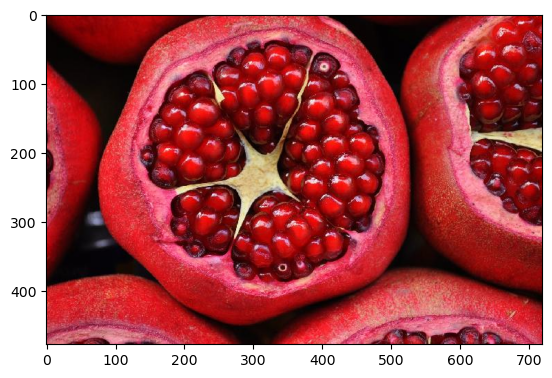

In [3]:
delima = cv2.imread("delima.jpg")
delima = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(delima)
plt.show()
#202331175_Rizalwirap

In [4]:
img.shape
#202331066_M.Kahlil Ghibran

(478, 720, 3)

In [5]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#202331066_M.Kahlil Ghibran

# Ketetanggan Piksel

In [6]:
copyCitra = img.copy().astype('float')

m1, n1 = copyCitra.shape
output1 = np.zeros((m1, n1)) 

print("Shape CopyCitra : ", copyCitra.shape)
print("Shape output1 : ", output1.shape)
print()
print("m1 : ", m1)
print("n1 : ", n1)
#202331066_M.Kahlil Ghibran

Shape CopyCitra :  (478, 720)
Shape output1 :  (478, 720)

m1 :  478
n1 :  720


# Membuat Filter Rata-Rata

In [7]:
for baris in range(1, m1-1):      
    for kolom in range(1, n1-1):  
        a = baris
        b = kolom
        
        jumlah = copyCitra[a-1,b-1] + copyCitra[a-1,b] + copyCitra[a-1,b+1] + \
                 copyCitra[a,b-1]   + copyCitra[a,b]   + copyCitra[a,b+1]   + \
                 copyCitra[a+1,b-1] + copyCitra[a+1,b] + copyCitra[a+1,b+1]

        output1[a,b] = (1/9) * jumlah
#202331066_M.Kahlil Ghibran

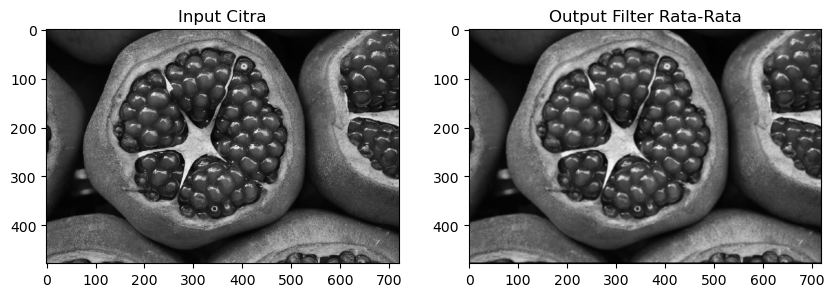

In [8]:
output1_display = output1.astype('uint8')

fig, axs = plt.subplots(1,2, figsize=(10,10))
ax = axs.ravel()

ax[0].imshow(img, cmap='gray')
ax[0].set_title("Input Citra")

ax[1].imshow(output1_display, cmap='gray')
ax[1].set_title("Output Filter Rata-Rata")

plt.show()
#202331066_M.Kahlil Ghibran

# Membuat Filter Median

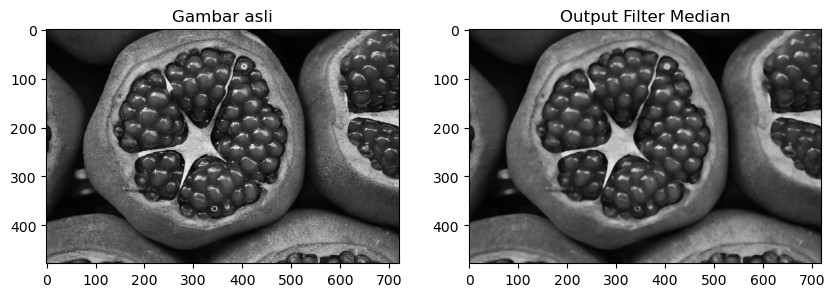

In [9]:
img_median = img.copy()
img_median = cv2.cvtColor(img_median, cv2.COLOR_BGR2RGB)
img_median_after = cv2.medianBlur(img_median, 5)

fig, axs = plt.subplots(1,2, figsize=(10,10))
ax = axs.ravel()

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Gambar asli')

ax[1].imshow(img_median_after, cmap='gray')
ax[1].set_title('Output Filter Median')
plt.show()
#202331066_M.Kahlil Ghibran

# Membuat Filter Batas

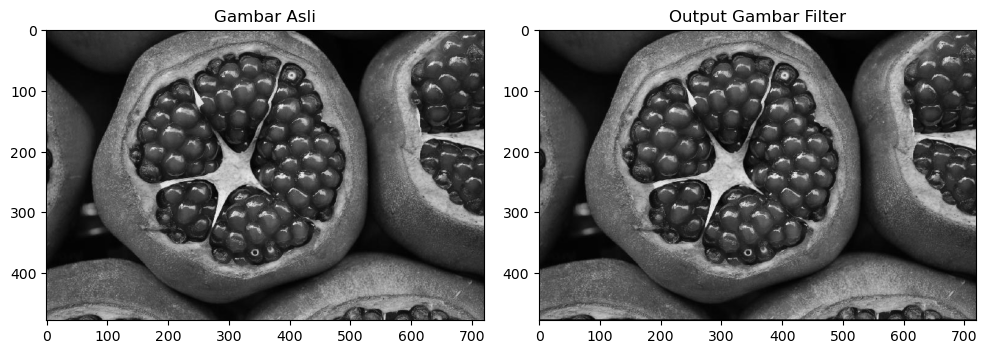

In [10]:
citra1 = img.copy().astype(float)
output1 = np.zeros_like(citra1)

for baris in range(1, m1-1):
    for kolom in range(1, n1-1):  
        
        arr = np.array([
            citra1[baris-1, kolom-1], citra1[baris-1, kolom], citra1[baris-1, kolom+1],
            citra1[baris, kolom-1], citra1[baris, kolom], citra1[baris, kolom+1],
            citra1[baris+1, kolom-1], citra1[baris+1, kolom], citra1[baris+1, kolom+1]
        ])
        
        minPiksel = np.amin(arr)
        maxPiksel = np.amax(arr)
        
        if citra1[baris, kolom] < minPiksel:
            output1[baris, kolom] = minPiksel
        elif citra1[baris, kolom] > maxPiksel:
            output1[baris, kolom] = maxPiksel
        else:
            output1[baris, kolom] = citra1[baris, kolom]

fig, axs = plt.subplots(1, 2, figsize=(10, 10))
ax = axs.ravel()

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Gambar Asli')
ax[1].imshow(output1, cmap='gray')
ax[1].set_title('Output Gambar Filter')
plt.tight_layout()
plt.show()
#202331066_M.Kahlil Ghibran